# Predicting EV Purchases
## Deep EDA — What Drives Electric Vehicle Adoption?

**Kaggle Playground Series — Season 6, Episode 9**

---

### Objective

What separates someone who **will buy an electric vehicle** from someone who won't?

In this notebook, we explore the dataset from multiple angles:

- Dataset structure and data quality
- Target distribution and class imbalance
- Numerical feature distributions
- Categorical feature behavior
- Statistical significance testing
- Feature interactions
- Correlation and multicollinearity
- Outlier analysis
- Practical feature importance conclusions

> **Key question:** Are EV purchases mainly driven by demographics, economics, infrastructure, incentives, or attitudes toward EVs?

### Dataset at a glance

| Property | Value |
|---|---:|
| Training rows | 668,665 |
| Features | 13 |
| Target | `Will_Buy_EV` |
| Problem type | Binary classification |
| Evaluation metric | ROC-AUC |


## Notebook Roadmap

**01** — Load & inspect the data  
**02** — Target distribution  
**03** — Numerical feature analysis  
**04** — Numerical features vs target  
**05** — Statistical significance  
**06** — Categorical feature analysis  
**07** — The strongest decision drivers  
**08** — Feature interactions  
**09** — Correlation & multicollinearity  
**10** — Outlier detection  
**11** — Final takeaways


In [1]:
# Core libraries
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import mannwhitneyu, chi2_contingency

warnings.filterwarnings("ignore")

# Visual style
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["figure.titlesize"] = 16

print("Libraries loaded successfully.")


Libraries loaded successfully.


## 01. Load & Inspect the Data


In [2]:
# Discover available files on Kaggle instead of relying on one hard-coded path.
input_files = []

for dirname, _, filenames in os.walk("/kaggle/input"):
    for filename in filenames:
        input_files.append(os.path.join(dirname, filename))

print("Files available under /kaggle/input:")
for path in input_files:
    print(" •", path)

train_candidates = [
    path for path in input_files
    if os.path.basename(path).lower() == "train.csv"
]

if not train_candidates:
    raise FileNotFoundError(
        "train.csv was not found under /kaggle/input. "
        "Please attach the competition dataset before running the notebook."
    )

train_path = train_candidates[0]
print(f"\nUsing: {train_path}")

df = pd.read_csv(train_path)

print(f"Shape: {df.shape}")
display(df.head())


Files available under /kaggle/input:
 • /kaggle/input/competitions/playground-series-s6e9/sample_submission.csv
 • /kaggle/input/competitions/playground-series-s6e9/train.csv
 • /kaggle/input/competitions/playground-series-s6e9/test.csv

Using: /kaggle/input/competitions/playground-series-s6e9/train.csv
Shape: (668665, 15)


,id,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,Gender,City_Type,Current_Car_Type,Home_Charging_Possible,Subsidy_Available,Range_Anxiety_Level,Will_Buy_EV
0,0,66,92887.0,23.4,2,3,7,1.0,Male,Suburban,Sedan,Yes,No,Low,No
1,1,38,30000.0,5.0,1,2,2,4.0,Male,Rural,SUV,Yes,No,Low,No
2,2,26,94389.0,36.8,1,8,15,5.0,Female,Urban,Sedan,No,Yes,Low,Yes
3,3,66,73580.0,23.7,2,6,9,3.0,Male,Suburban,Hatchback,Yes,No,Low,No
4,4,54,57898.0,50.8,1,2,3,3.0,Male,Suburban,Hatchback,Yes,No,Low,No


In [3]:
print("Dataset information")
print("=" * 60)
df.info()


Dataset information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 668665 entries, 0 to 668664
Data columns (total 15 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   id                           668665 non-null  int64  
 1   Age                          668665 non-null  int64  
 2   Annual_Income_USD            668665 non-null  float64
 3   Daily_Commute_km             668665 non-null  float64
 4   Number_of_Cars_Owned         668665 non-null  int64  
 5   Charging_Stations_Near_Home  668665 non-null  int64  
 6   Charging_Stations_Near_Work  668665 non-null  int64  
 7   Environmental_Concern_Level  668665 non-null  float64
 8   Gender                       668665 non-null  object 
 9   City_Type                    668665 non-null  object 
 10  Current_Car_Type             668665 non-null  object 
 11  Home_Charging_Possible       668665 non-null  object 
 12  Subsidy_Available            668665 no

In [4]:
# Compact data-quality audit
quality = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing": df.isna().sum(),
    "missing_%": (df.isna().mean() * 100).round(3),
    "unique": df.nunique()
})

display(quality)


,dtype,missing,missing_%,unique
id,int64,0,0.0,668665
Age,int64,0,0.0,45
Annual_Income_USD,float64,0,0.0,13214
Daily_Commute_km,float64,0,0.0,805
Number_of_Cars_Owned,int64,0,0.0,4
Charging_Stations_Near_Home,int64,0,0.0,15
Charging_Stations_Near_Work,int64,0,0.0,20
Environmental_Concern_Level,float64,0,0.0,5
Gender,object,0,0.0,3
City_Type,object,0,0.0,3


### 💡 Insight — Data Quality

The dataset contains **668,665 training observations** and has a clean structure.

The most important data-quality finding is the absence of missing values across the feature set, meaning:

- No imputation is required for the EDA.
- We can analyze every observation directly.
- Categorical and numerical relationships can be examined without first repairing missing data.

The feature set contains a mixture of demographic, financial, mobility, infrastructure, and behavioral variables.


## 02. Target Distribution


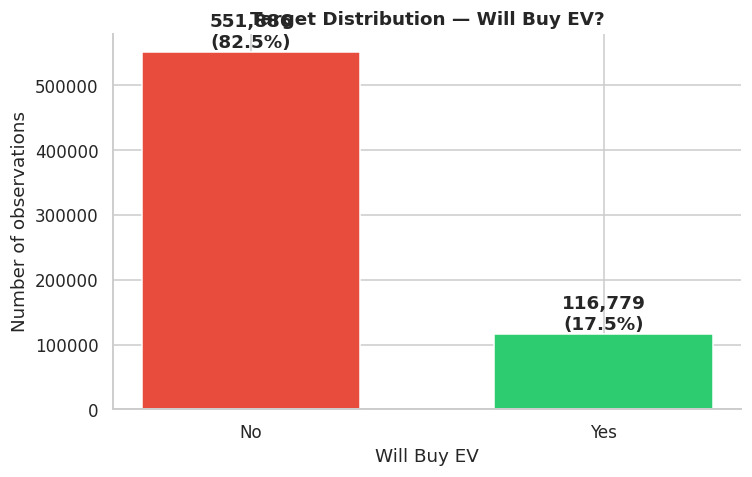

Target distribution:


,Count,Percentage
Will_Buy_EV,,
No,551886,82.54
Yes,116779,17.46


In [5]:
target = "Will_Buy_EV"

target_counts = df[target].value_counts()
target_pct = df[target].value_counts(normalize=True) * 100

fig, ax = plt.subplots(figsize=(7, 4.5))

bars = ax.bar(
    target_counts.index,
    target_counts.values,
    width=0.62,
    color=["#E74C3C", "#2ECC71"]
)

ax.set_title("Target Distribution — Will Buy EV?")
ax.set_xlabel("Will Buy EV")
ax.set_ylabel("Number of observations")

for bar, count, pct in zip(bars, target_counts.values, target_pct.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{count:,}\n({pct:.1f}%)",
        ha="center",
        va="bottom",
        fontweight="bold"
    )

sns.despine()
plt.tight_layout()
plt.show()

print("Target distribution:")
display(
    pd.DataFrame({
        "Count": target_counts,
        "Percentage": target_pct.round(2)
    })
)


In [6]:
no_count = (df[target] == "No").sum()
yes_count = (df[target] == "Yes").sum()

print(f"No  : {no_count:,} ({no_count / len(df) * 100:.2f}%)")
print(f"Yes : {yes_count:,} ({yes_count / len(df) * 100:.2f}%)")
print(f"Approximate No:Yes ratio = {no_count / yes_count:.2f}:1")


No  : 551,886 (82.54%)
Yes : 116,779 (17.46%)
Approximate No:Yes ratio = 4.73:1


### 💡 Insight — Strong Class Imbalance

The target is heavily imbalanced:

- **82.54%** of observations are `No`
- **17.46%** are `Yes`
- That's roughly a **5:1 imbalance**

This matters when evaluating models.

A model that predicts `No` for everyone would already achieve about **82.5% accuracy**, despite being useless at identifying potential EV buyers.

Therefore, **ROC-AUC** is much more informative for this competition than raw accuracy.

> ⚠️ The imbalance should also be considered during model development through appropriate validation, threshold analysis, class weighting, or other imbalance-aware techniques.


## 03. Numerical Feature Analysis


In [7]:
# Identify numerical columns while excluding the identifier.
num_cols = df.select_dtypes(include=np.number).columns.tolist()
num_cols = [c for c in num_cols if c.lower() not in ["id", "index"]]

print("Numerical features:")
print(num_cols)

display(df[num_cols].describe().T.round(2))


Numerical features:
['Age', 'Annual_Income_USD', 'Daily_Commute_km', 'Number_of_Cars_Owned', 'Charging_Stations_Near_Home', 'Charging_Stations_Near_Work', 'Environmental_Concern_Level']


,count,mean,std,min,25%,50%,75%,max
Age,668665.0,47.04,12.88,25.0,36.0,47.0,58.0,69.0
Annual_Income_USD,668665.0,84769.27,28648.03,30000.0,67376.0,84880.0,102753.0,188549.0
Daily_Commute_km,668665.0,32.16,18.73,5.0,17.2,33.6,47.4,98.7
Number_of_Cars_Owned,668665.0,1.71,0.73,1.0,1.0,2.0,2.0,4.0
Charging_Stations_Near_Home,668665.0,4.96,3.93,0.0,2.0,4.0,7.0,14.0
Charging_Stations_Near_Work,668665.0,7.18,5.19,0.0,3.0,6.0,10.0,19.0
Environmental_Concern_Level,668665.0,2.94,1.43,1.0,2.0,3.0,4.0,5.0


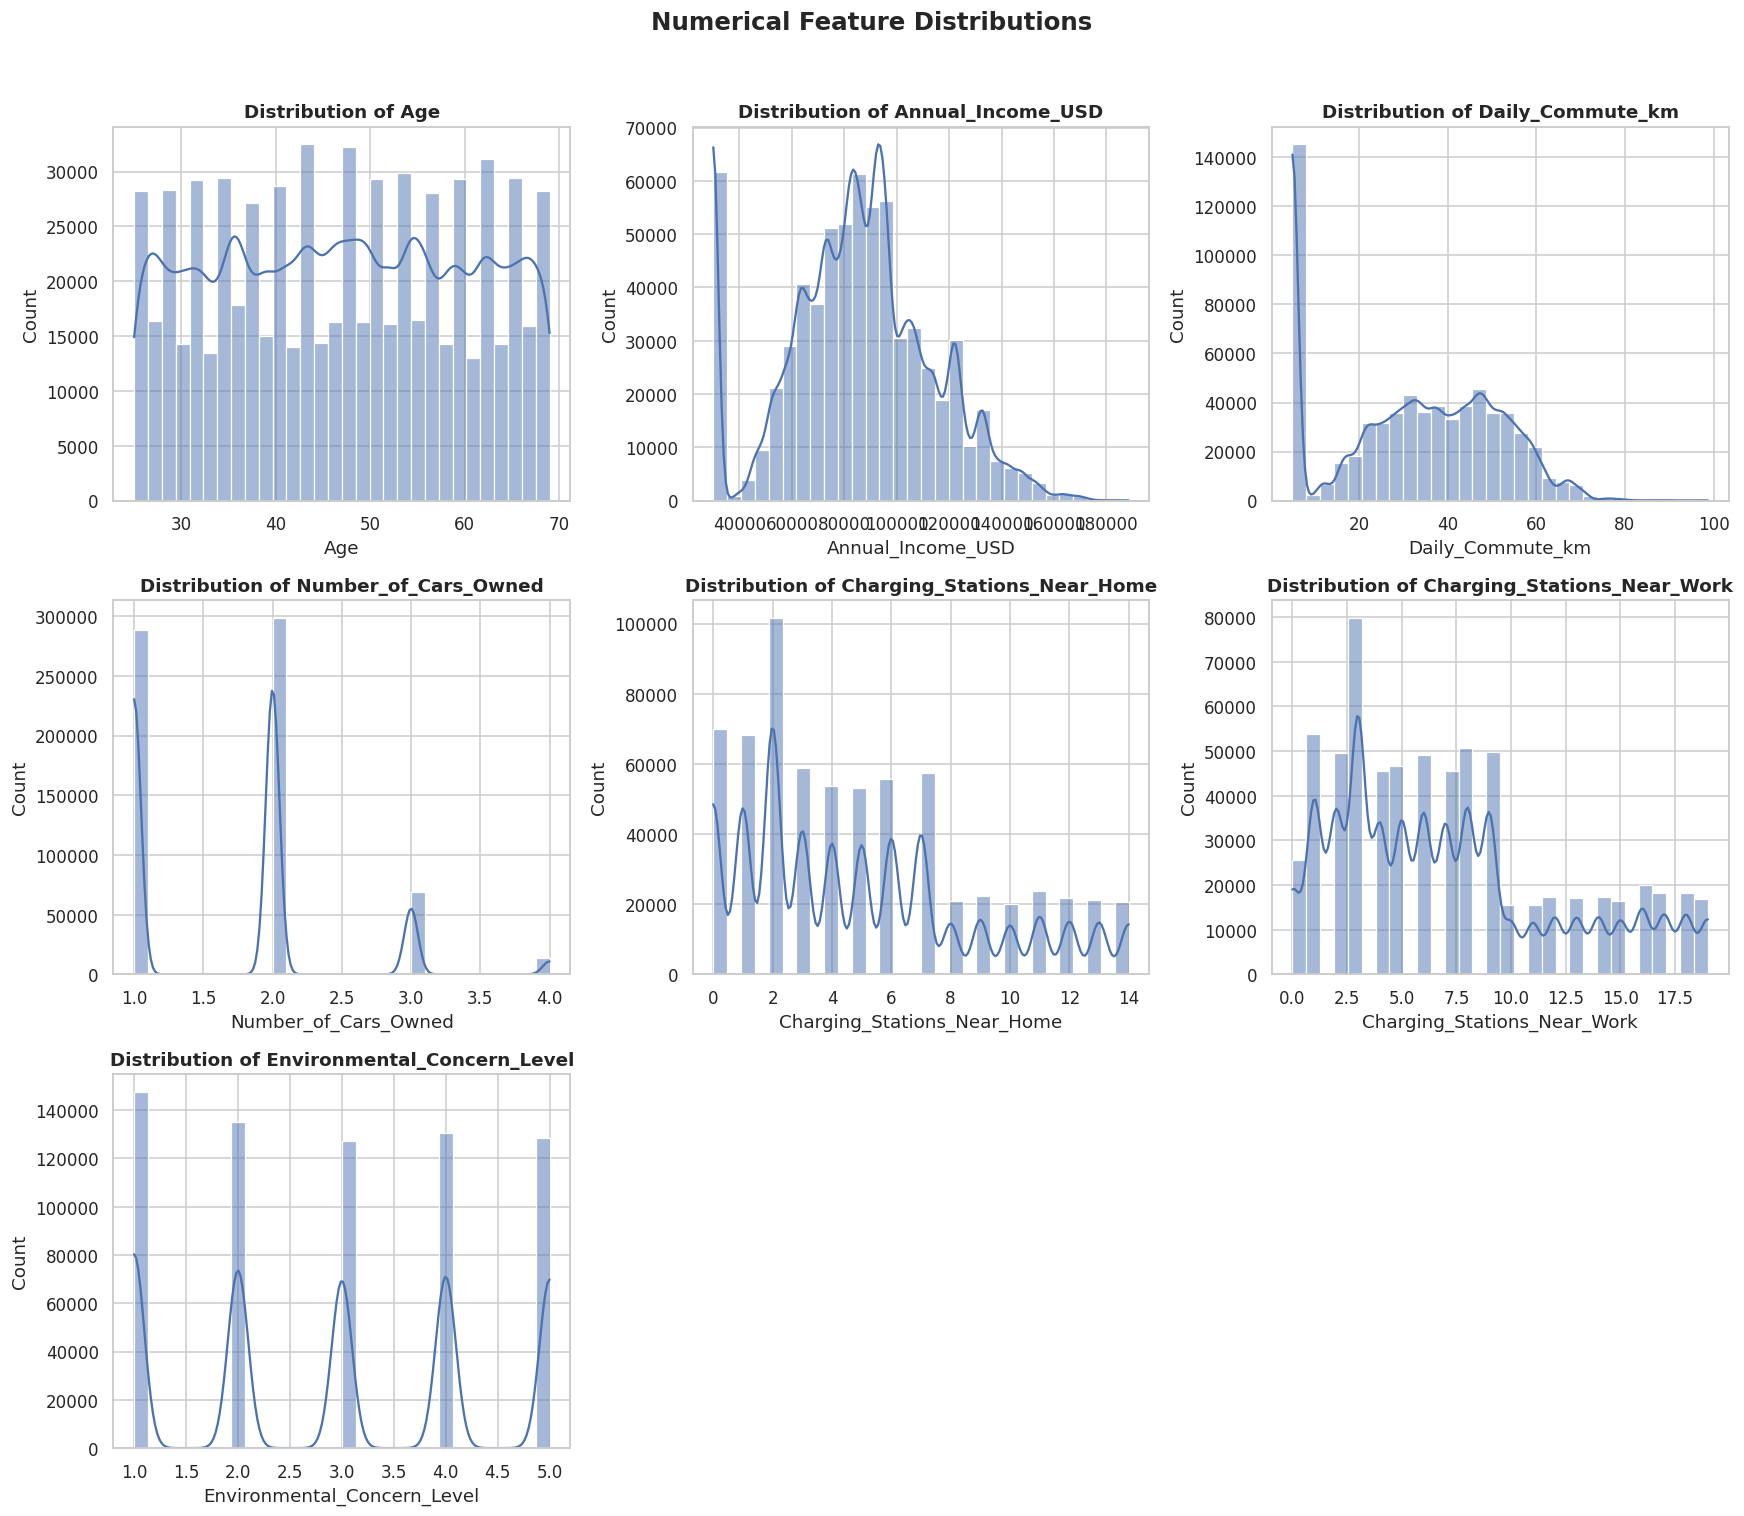

In [8]:
# Distribution overview
n = len(num_cols)
ncols = 3
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4.5 * nrows))
axes = np.array(axes).reshape(-1)

for ax, col in zip(axes, num_cols):
    sns.histplot(
        data=df,
        x=col,
        bins=30,
        kde=True,
        ax=ax
    )
    ax.set_title(f"Distribution of {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Count")

for ax in axes[n:]:
    ax.remove()

plt.suptitle("Numerical Feature Distributions", y=1.02, fontweight="bold")
plt.tight_layout()
plt.show()


### 💡 Insight — Numerical Distributions

Several patterns stand out:

- **Age:** Broadly distributed across the adult population, with no extreme concentration at one end.
- **Annual_Income_USD:** More right-skewed than the other numerical variables, reflecting a smaller group of high-income observations.
- **Daily_Commute_km:** Most observations fall in a moderate commuting range, with relatively few long-distance commuters.
- **Number_of_Cars_Owned:** Most people own 1–2 cars; ownership of 3–4 cars is much less common.
- **Charging_Stations_Near_Home / Work:** Infrastructure-related counts have relatively broad distributions.
- **Environmental_Concern_Level:** The score is spread across its available range rather than being concentrated at a single value.

These distributions do not, by themselves, tell us whether a feature predicts EV adoption. The next step is to compare them against the target.


## 04. Numerical Features vs Target


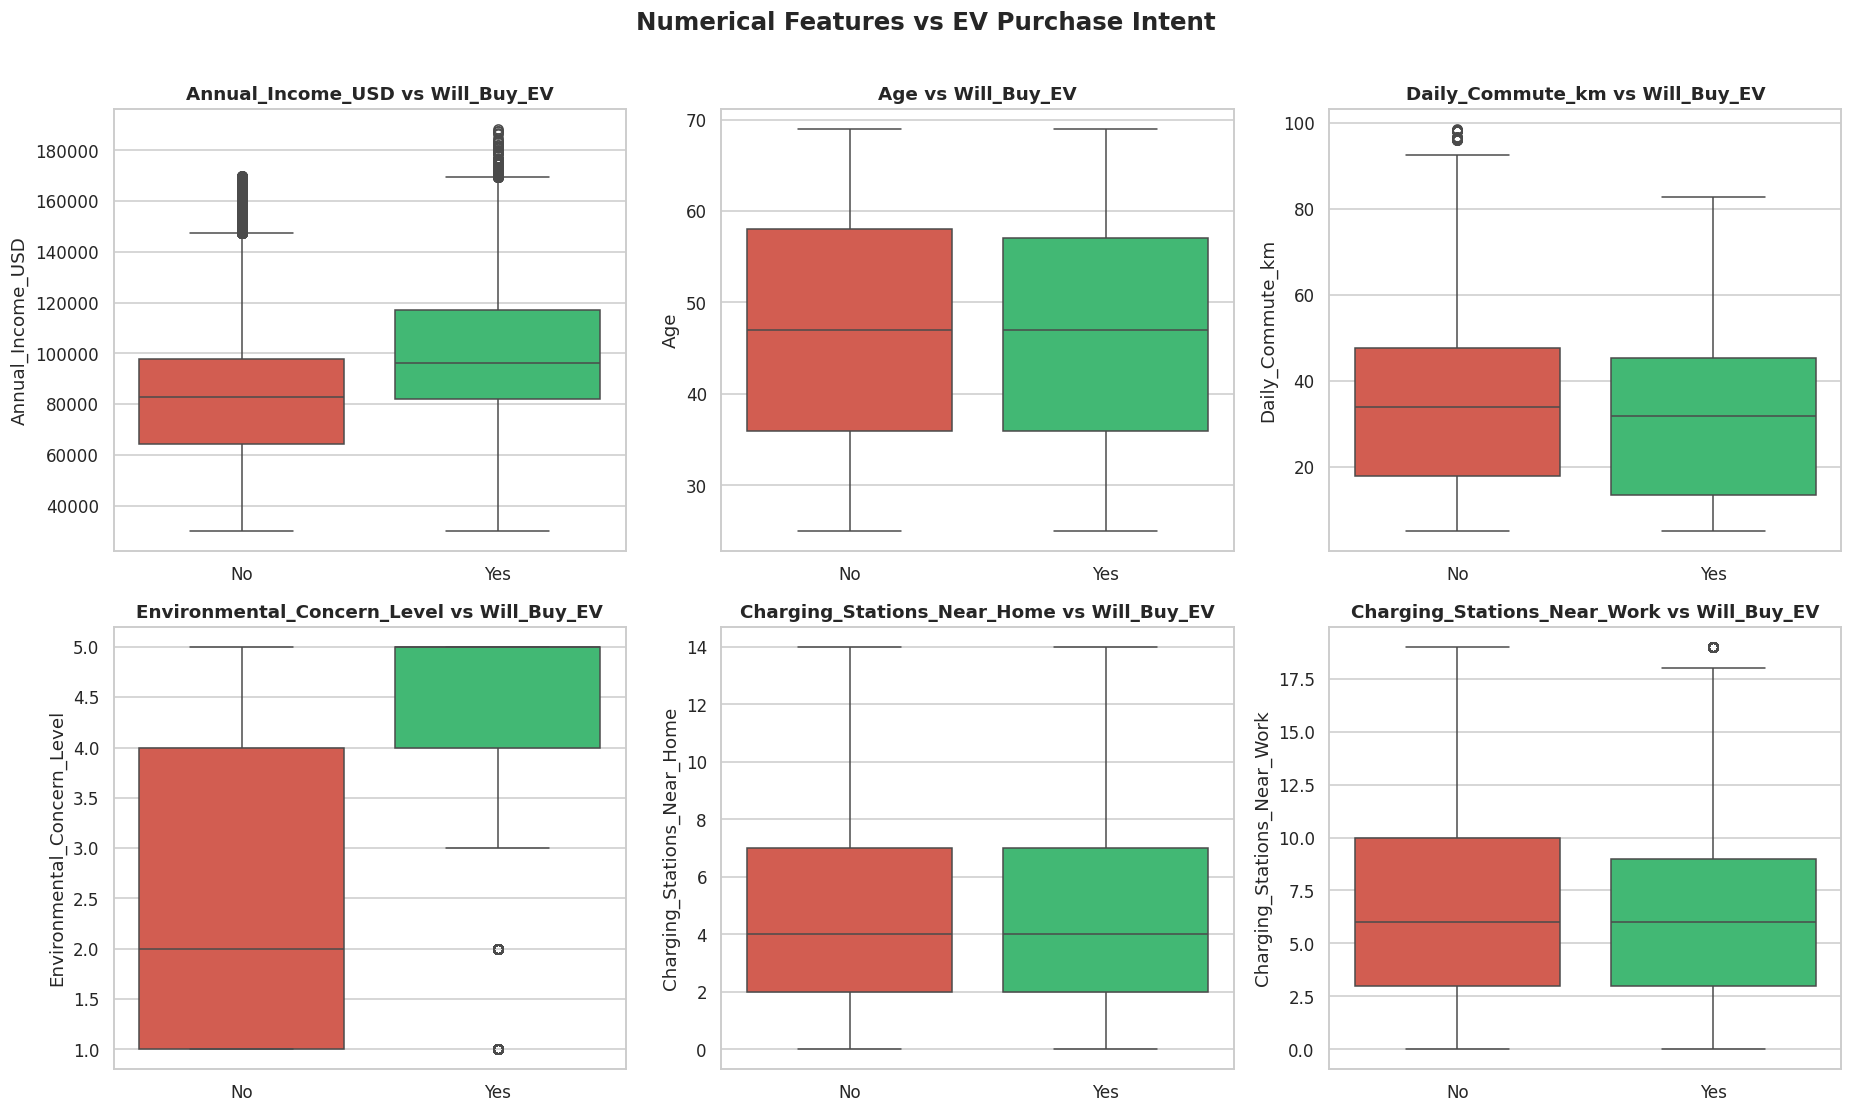

In [9]:
# Boxplots reveal how the distributions differ between buyers and non-buyers.
plot_cols = [
    "Annual_Income_USD",
    "Age",
    "Daily_Commute_km",
    "Environmental_Concern_Level",
    "Charging_Stations_Near_Home",
    "Charging_Stations_Near_Work"
]

fig, axes = plt.subplots(2, 3, figsize=(17, 10))
axes = axes.flatten()

for ax, col in zip(axes, plot_cols):
    sns.boxplot(
        data=df,
        x=target,
        y=col,
        ax=ax,
        palette=["#E74C3C", "#2ECC71"]
    )
    ax.set_title(f"{col} vs {target}")
    ax.set_xlabel("")

plt.suptitle("Numerical Features vs EV Purchase Intent", y=1.01, fontweight="bold")
plt.tight_layout()
plt.show()


In [10]:
# Compare group medians in one table.
group_summary = (
    df.groupby(target)[plot_cols]
      .median()
      .T
      .rename(columns={"No": "Median — No", "Yes": "Median — Yes"})
)

group_summary["Absolute Difference"] = (
    group_summary["Median — Yes"] - group_summary["Median — No"]
)

display(group_summary.round(2))


Will_Buy_EV,Median — No,Median — Yes,Absolute Difference
Annual_Income_USD,82844.0,96167.0,13323.0
Age,47.0,47.0,0.0
Daily_Commute_km,34.0,31.7,-2.3
Environmental_Concern_Level,2.0,5.0,3.0
Charging_Stations_Near_Home,4.0,4.0,0.0
Charging_Stations_Near_Work,6.0,6.0,0.0


### 💡 Insight — Numerical Features vs Target

**Annual income is one of the clearest numerical differences.**

EV buyers tend to have higher incomes than non-buyers, which is economically intuitive: vehicle purchase price, financing capacity, and access to charging infrastructure can all interact with household income.

Other notable patterns:

- **Environmental concern:** buyers tend to have higher environmental-concern scores.
- **Charging infrastructure:** buyers tend to have somewhat greater access to charging infrastructure.
- **Daily commute:** the distributions differ, although the effect is less dramatic than the strongest categorical drivers.
- **Age:** the buyer and non-buyer distributions overlap substantially, suggesting that age alone is unlikely to be a dominant predictor.

The important distinction is that a visible difference does not automatically mean a feature has a large predictive effect. Statistical testing helps quantify whether these differences are unlikely to be random.


## 05. Statistical Significance Testing


### Numerical variables — Mann–Whitney U test

Because several numerical variables are not guaranteed to follow a normal distribution, we use the **Mann–Whitney U test** to compare the distributions of buyers and non-buyers.

**Null hypothesis:** the two target groups come from the same distribution.

A small p-value provides evidence that the distributions differ.

> **Important:** statistical significance does not measure predictive strength. With hundreds of thousands of observations, even small differences can become statistically significant.


In [11]:
numerical_test_cols = [
    "Age",
    "Annual_Income_USD",
    "Daily_Commute_km",
    "Number_of_Cars_Owned",
    "Charging_Stations_Near_Home",
    "Charging_Stations_Near_Work",
    "Environmental_Concern_Level"
]

mw_results = []

for col in numerical_test_cols:
    group_yes = df.loc[df[target] == "Yes", col]
    group_no = df.loc[df[target] == "No", col]

    statistic, p_value = mannwhitneyu(
        group_yes,
        group_no,
        alternative="two-sided"
    )

    mw_results.append({
        "Feature": col,
        "U statistic": statistic,
        "p-value": p_value,
        "Significant (α=0.05)": p_value < 0.05
    })

mw_results = pd.DataFrame(mw_results)
display(mw_results.style.format({
    "U statistic": "{:,.0f}",
    "p-value": "{:.3e}"
}))


,Feature,U statistic,p-value,Significant (α=0.05)
0,Age,"31,867,593,870",2.606e-09,True
1,Annual_Income_USD,"43,204,263,682",0.000e+00,True
2,Daily_Commute_km,"30,048,756,811",1.723e-291,True
3,Number_of_Cars_Owned,"32,477,921,540",3.418e-06,True
4,Charging_Stations_Near_Home,"31,200,497,762",5.194e-66,True
5,Charging_Stations_Near_Work,"31,539,915,974",2.346e-30,True
6,Environmental_Concern_Level,"54,363,849,794",0.000e+00,True


### Categorical variables — Chi-square test

For categorical variables, we use the **Chi-square test of independence**.

**Null hypothesis:** the categorical feature and EV purchase intent are independent.

A very small p-value suggests an association exists.

Again, with a dataset this large, **p-value alone should never be used to rank features**. We also inspect actual purchase rates and group differences.


In [12]:
categorical_cols = [
    "Gender",
    "City_Type",
    "Current_Car_Type",
    "Home_Charging_Possible",
    "Subsidy_Available",
    "Range_Anxiety_Level"
]

chi_results = []

for col in categorical_cols:
    contingency = pd.crosstab(df[col], df[target])

    chi2, p_value, dof, expected = chi2_contingency(contingency)

    chi_results.append({
        "Feature": col,
        "Chi-square": chi2,
        "p-value": p_value,
        "Significant (α=0.05)": p_value < 0.05
    })

chi_results = pd.DataFrame(chi_results)

display(chi_results.style.format({
    "Chi-square": "{:,.2f}",
    "p-value": "{:.3e}"
}))


,Feature,Chi-square,p-value,Significant (α=0.05)
0,Gender,33.04,6.688e-08,True
1,City_Type,742.83,4.971e-162,True
2,Current_Car_Type,173.66,2.060e-37,True
3,Home_Charging_Possible,"4,671.04",0.000e+00,True
4,Subsidy_Available,"78,382.50",0.000e+00,True
5,Range_Anxiety_Level,"8,981.91",0.000e+00,True


### 💡 Insight — Statistical Significance vs Practical Importance

With a dataset of this size, **extremely small p-values are expected whenever a feature has even a modest association with the target**.

The correct interpretation is:

> **Statistical significance tells us that an association exists. It does not tell us how useful or powerful the feature is.**

That is why the next analysis focuses on **actual EV purchase rates within each category**.


## 06. Categorical Feature Analysis


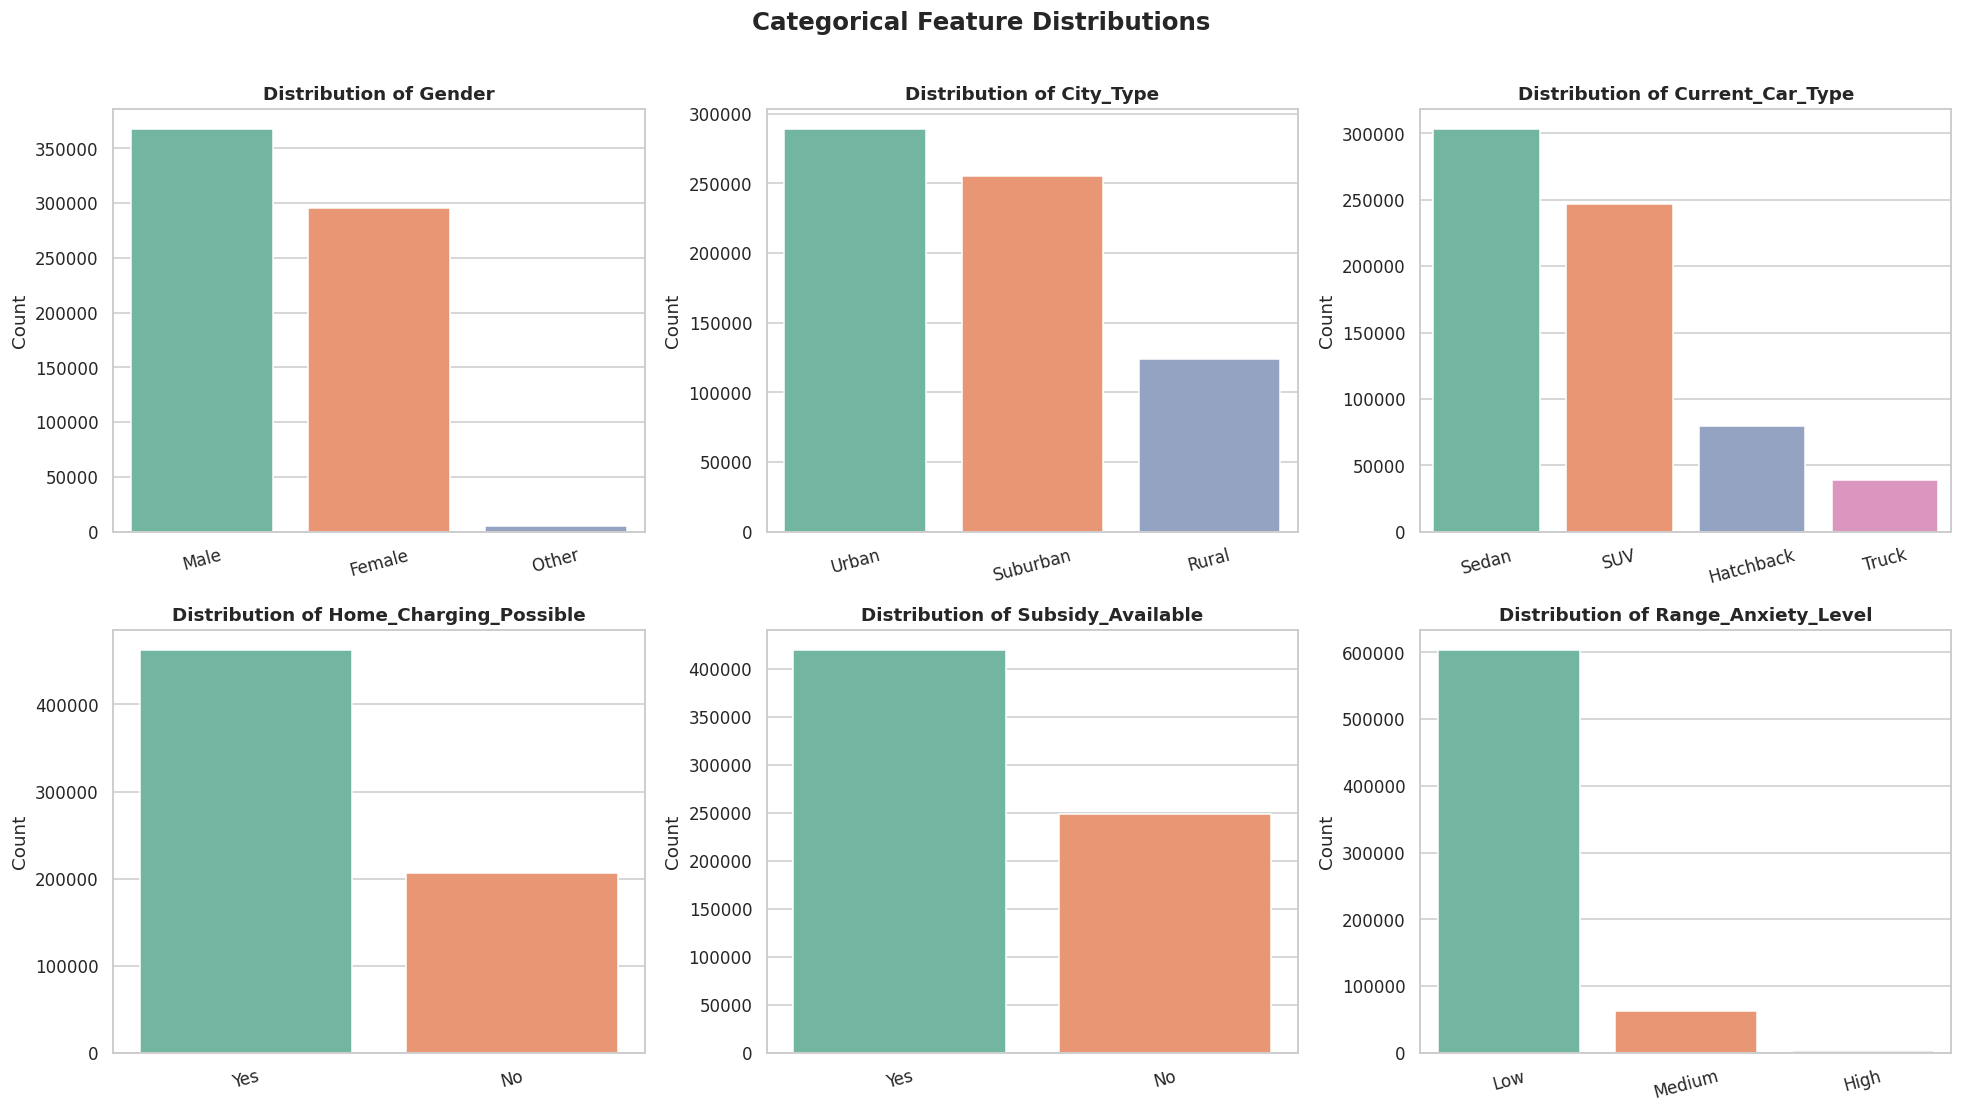

In [13]:
# Distribution of categorical features
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, col in zip(axes, categorical_cols):
    order = df[col].value_counts().index

    sns.countplot(
        data=df,
        x=col,
        order=order,
        ax=ax,
        palette="Set2"
    )

    ax.set_title(f"Distribution of {col}")
    ax.set_xlabel("")
    ax.set_ylabel("Count")
    ax.tick_params(axis="x", rotation=15)

plt.suptitle("Categorical Feature Distributions", y=1.01, fontweight="bold")
plt.tight_layout()
plt.show()


In [14]:
# Purchase rate within each category.
for col in categorical_cols:
    rate_table = (
        pd.crosstab(
            df[col],
            df[target],
            normalize="index"
        ) * 100
    )

    print("=" * 70)
    print(col)
    display(rate_table.round(2))


Gender


Will_Buy_EV,No,Yes
Gender,,
Female,82.24,17.76
Male,82.77,17.23
Other,82.63,17.37


City_Type


Will_Buy_EV,No,Yes
City_Type,,
Rural,80.66,19.34
Suburban,81.91,18.09
Urban,83.89,16.11


Current_Car_Type


...

Will_Buy_EV,No,Yes
Home_Charging_Possible,,
No,87.29,12.71
Yes,80.42,19.58


Subsidy_Available


Will_Buy_EV,No,Yes
Subsidy_Available,,
No,99.42,0.58
Yes,72.53,27.47


Range_Anxiety_Level


Will_Buy_EV,No,Yes
Range_Anxiety_Level,,
High,99.86,0.14
Low,81.10,18.90
Medium,95.83,4.17


## 07. The Strongest Decision Drivers


In [15]:
# Build a reusable purchase-rate table for each categorical feature.
purchase_rate_tables = {}

for col in categorical_cols:
    table = (
        df.groupby(col)[target]
          .apply(lambda s: (s == "Yes").mean() * 100)
          .sort_values(ascending=False)
          .rename("EV Buy Rate (%)")
          .to_frame()
    )
    purchase_rate_tables[col] = table

# Rank categorical features by their spread in purchase rates.
categorical_impact = []

for col, table in purchase_rate_tables.items():
    categorical_impact.append({
        "Feature": col,
        "Highest buy rate (%)": table["EV Buy Rate (%)"].max(),
        "Lowest buy rate (%)": table["EV Buy Rate (%)"].min(),
        "Spread (percentage points)": (
            table["EV Buy Rate (%)"].max() -
            table["EV Buy Rate (%)"].min()
        )
    })

categorical_impact = (
    pd.DataFrame(categorical_impact)
      .sort_values("Spread (percentage points)", ascending=False)
)

display(categorical_impact.round(2))


,Feature,Highest buy rate (%),Lowest buy rate (%),Spread (percentage points)
4,Subsidy_Available,27.47,0.58,26.89
5,Range_Anxiety_Level,18.90,0.14,18.77
3,Home_Charging_Possible,19.58,12.71,6.87
1,City_Type,19.34,16.11,3.23
2,Current_Car_Type,18.10,15.64,2.45
0,Gender,17.76,17.23,0.54


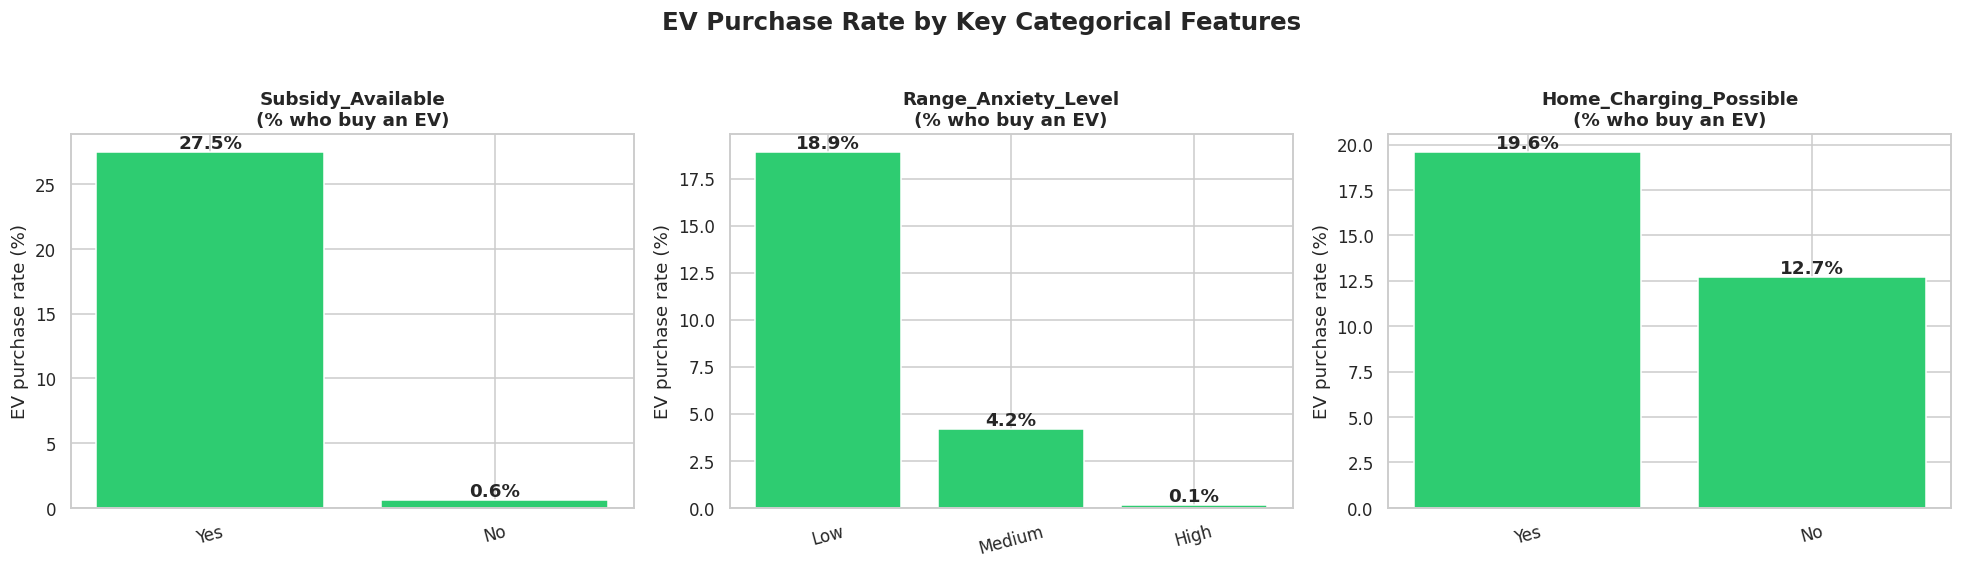

In [16]:
# Visualize the three strongest categorical drivers.
key_categorical = [
    "Subsidy_Available",
    "Range_Anxiety_Level",
    "Home_Charging_Possible"
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col in zip(axes, key_categorical):
    rates = (
        df.groupby(col)[target]
          .apply(lambda s: (s == "Yes").mean() * 100)
          .sort_values(ascending=False)
    )

    bars = ax.bar(
        rates.index.astype(str),
        rates.values,
        color="#2ECC71",
        edgecolor="white"
    )

    ax.set_title(f"{col}\n(% who buy an EV)")
    ax.set_ylabel("EV purchase rate (%)")
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=15)

    for bar, value in zip(bars, rates.values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            value,
            f"{value:.1f}%",
            ha="center",
            va="bottom",
            fontweight="bold"
        )

plt.suptitle("EV Purchase Rate by Key Categorical Features", y=1.03, fontweight="bold")
plt.tight_layout()
plt.show()


### 💡 Insight — Subsidies Stand Out

Among the categorical variables, **`Subsidy_Available` is by far the strongest practical signal**.

The purchase rate changes dramatically depending on whether a subsidy is available:

- **No subsidy → ~0.6% buy rate**
- **Subsidy available → ~27.5% buy rate**

This is an enormous difference.

`Range_Anxiety_Level` is another powerful discriminator:

- Low range anxiety is associated with a much higher purchase rate.
- High range anxiety is associated with an extremely low purchase rate.

`Home_Charging_Possible` also matters, but its effect is much smaller than the subsidy effect.

By contrast:

- **Gender:** only a small difference in purchase rate.
- **Current car type:** relatively modest separation.
- **City type:** noticeable, but still much weaker than subsidy and range anxiety.

> **Practical takeaway:** financial incentives and perceived usability appear to matter much more than basic demographics.


## 08. Feature Interaction — Home Charging × Subsidy


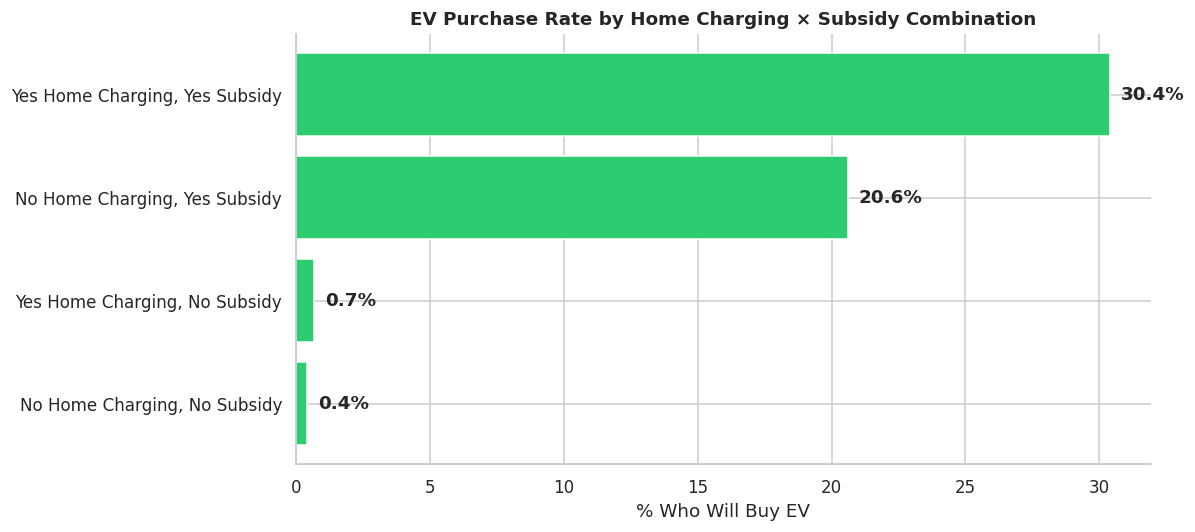

Will_Buy_EV,No,Yes
row_0,,
"No Home Charging, No Subsidy",99.60,0.40
"Yes Home Charging, No Subsidy",99.34,0.66
"No Home Charging, Yes Subsidy",79.40,20.60
"Yes Home Charging, Yes Subsidy",69.60,30.40


In [17]:
# Combine the two strongest infrastructure/economic variables.
combo_col = (
    df["Home_Charging_Possible"].astype(str)
    + " Home Charging, "
    + df["Subsidy_Available"].astype(str)
    + " Subsidy"
)

combo = (
    pd.crosstab(combo_col, df[target], normalize="index") * 100
)

combo = combo.sort_values("Yes")

fig, ax = plt.subplots(figsize=(11, 5))

bars = ax.barh(
    combo.index,
    combo["Yes"],
    color="#2ECC71"
)

ax.set_title(
    "EV Purchase Rate by Home Charging × Subsidy Combination"
)
ax.set_xlabel("% Who Will Buy EV")

for bar, value in zip(bars, combo["Yes"]):
    ax.text(
        value + 0.4,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.1f}%",
        va="center",
        fontweight="bold"
    )

sns.despine()
plt.tight_layout()
plt.show()

display(combo.round(2))


### 💡 Insight — The Golden Combination

The interaction between **subsidy availability and home charging** reveals an important pattern:

| Home Charging | Subsidy | EV Buy Rate |
|---|---|---:|
| No | No | **~0.4%** |
| Yes | No | **~0.7%** |
| No | Yes | **~20.6%** |
| Yes | Yes | **~30.4%** |

The striking observation is that **subsidy availability dominates the interaction**.

Without a subsidy, adding home charging access only moves the purchase rate slightly.

With a subsidy, however, home charging access provides an additional boost:

> **Subsidy + home charging = roughly 30% EV purchase rate.**

This suggests a potentially valuable interaction for downstream modeling: **economic incentive × infrastructure availability**.


## 09. Correlation & Multicollinearity


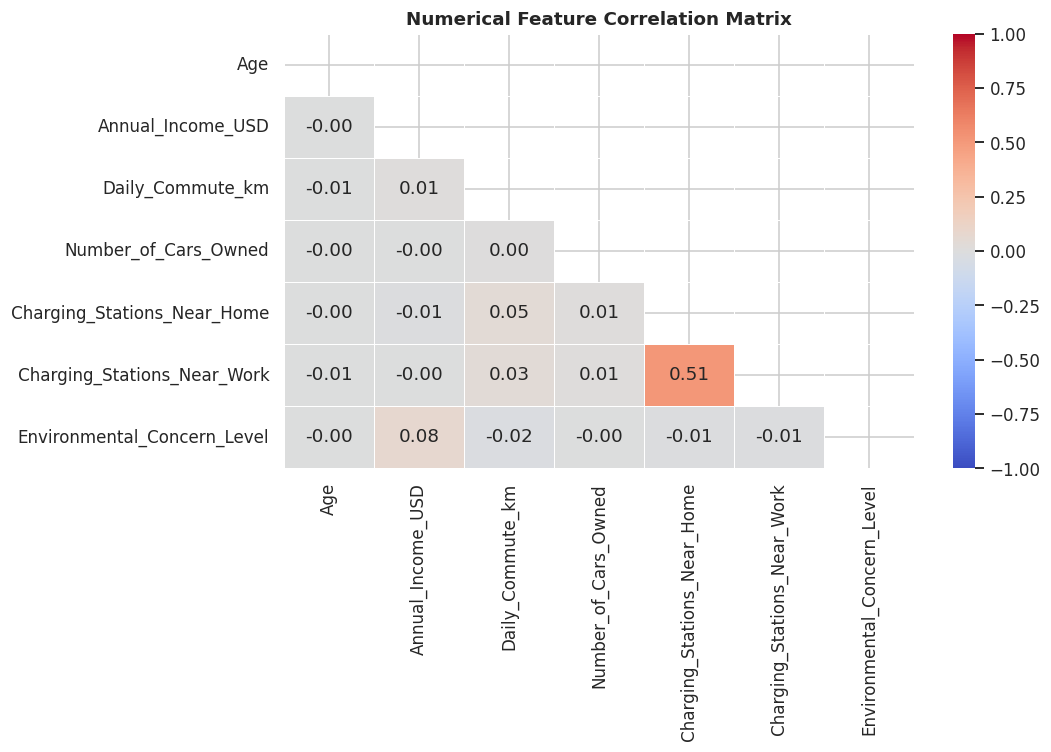

In [18]:
corr_cols = [
    "Age",
    "Annual_Income_USD",
    "Daily_Commute_km",
    "Number_of_Cars_Owned",
    "Charging_Stations_Near_Home",
    "Charging_Stations_Near_Work",
    "Environmental_Concern_Level"
]

corr = df[corr_cols].corr()

plt.figure(figsize=(10, 7))

mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    mask=mask,
    linewidths=0.5,
    vmin=-1,
    vmax=1
)

plt.title("Numerical Feature Correlation Matrix")
plt.tight_layout()
plt.show()


### 💡 Insight — Low Multicollinearity

Most numerical correlations are relatively small, indicating that the numerical variables capture different aspects of the population.

The most intuitive relationship is between:

- `Charging_Stations_Near_Home`
- `Charging_Stations_Near_Work`

Both describe access to charging infrastructure, so some correlation is expected.

Overall, there is no obvious numerical feature pair that appears so redundant that it must be removed before modeling.

For tree-based models such as **XGBoost, LightGBM, and CatBoost**, this level of multicollinearity is generally not a major concern.


## 10. Outlier Detection


In [19]:
# IQR-based outlier analysis
outlier_results = []

for col in corr_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    outlier_mask = (df[col] < lower) | (df[col] > upper)

    count = outlier_mask.sum()
    percentage = count / len(df) * 100

    outlier_results.append({
        "Feature": col,
        "Q1": q1,
        "Q3": q3,
        "Lower Bound": lower,
        "Upper Bound": upper,
        "Outliers": count,
        "Outlier %": percentage
    })

outlier_results = pd.DataFrame(outlier_results)

display(
    outlier_results.style.format({
        "Q1": "{:,.2f}",
        "Q3": "{:,.2f}",
        "Lower Bound": "{:,.2f}",
        "Upper Bound": "{:,.2f}",
        "Outliers": "{:,.0f}",
        "Outlier %": "{:.2f}%"
    })
)


,Feature,Q1,Q3,Lower Bound,Upper Bound,Outliers,Outlier %
0,Age,36.00,58.00,3.00,91.00,0,0.00%
1,Annual_Income_USD,"67,376.00","102,753.00","14,310.50","155,818.50","3,678",0.55%
2,Daily_Commute_km,17.20,47.40,-28.10,92.70,41,0.01%
3,Number_of_Cars_Owned,1.00,2.00,-0.50,3.50,"13,489",2.02%
4,Charging_Stations_Near_Home,2.00,7.00,-5.50,14.50,0,0.00%
5,Charging_Stations_Near_Work,3.00,10.00,-7.50,20.50,0,0.00%
6,Environmental_Concern_Level,2.00,4.00,-1.00,7.00,0,0.00%


### 💡 Insight — Minimal and Mostly Plausible Outliers

The IQR analysis shows relatively few observations outside the conventional 1.5×IQR boundaries.

Notable cases include:

- **Annual_Income_USD:** ~0.55% flagged as outliers.
- **Number_of_Cars_Owned:** ~2.02% flagged as outliers.
- Most other numerical features have very few or no IQR outliers.

These observations should **not automatically be deleted**.

For example, owning 3–4 cars or having a very high income can be completely legitimate.

> **Conclusion:** there is no strong EDA-based reason to perform blanket outlier removal. Tree-based models are also generally robust to extreme values.


## 11. Final Summary — What Actually Drives EV Adoption?


In [20]:
# Compact numerical comparison: median difference between target groups.
median_comparison = (
    df.groupby(target)[corr_cols]
      .median()
      .T
)

median_comparison["Absolute Difference"] = (
    median_comparison["Yes"] - median_comparison["No"]
).abs()

display(median_comparison.sort_values("Absolute Difference", ascending=False).round(2))


Will_Buy_EV,No,Yes,Absolute Difference
Annual_Income_USD,82844.0,96167.0,13323.0
Environmental_Concern_Level,2.0,5.0,3.0
Daily_Commute_km,34.0,31.7,2.3
Age,47.0,47.0,0.0
Number_of_Cars_Owned,2.0,2.0,0.0
Charging_Stations_Near_Home,4.0,4.0,0.0
Charging_Stations_Near_Work,6.0,6.0,0.0


## Key Findings

### 1. 🥇 Subsidies are the dominant categorical signal

`Subsidy_Available` produces the largest difference in EV purchase rates.

> **No subsidy → ~0.6% buy rate**  
> **Subsidy available → ~27.5% buy rate**

This is the clearest behavioral pattern in the dataset.

---

### 2. 🥈 Range anxiety is extremely important

People with **high range anxiety** are overwhelmingly unlikely to purchase an EV.

This makes intuitive sense: concerns about driving range can directly reduce willingness to switch from conventional vehicles.

---

### 3. 🥉 Home charging provides an additional advantage

Home charging matters, but its effect becomes much stronger when combined with financial incentives.

> **Subsidy + home charging → ~30.4% buy rate**

This interaction is more informative than looking at either feature in isolation.

---

### 4. 💰 Income separates buyers from non-buyers

EV buyers tend to have higher incomes.

This suggests that affordability and purchasing power are relevant components of EV adoption.

---

### 5. 🌱 Environmental concern carries meaningful signal

People willing to buy EVs tend to show higher environmental-concern scores.

This supports the idea that EV adoption is influenced by both **economic factors** and **attitudes/values**.

---

### 6. 👤 Demographics are weaker than behavioral/economic variables

Gender shows only a small difference in purchase rate.

City type and current vehicle type show some separation, but neither approaches the strength of subsidy availability or range anxiety.

---

### 🎯 Modeling implications

The strongest candidates for feature engineering and interaction analysis are:

- `Subsidy_Available`
- `Range_Anxiety_Level`
- `Home_Charging_Possible`
- `Annual_Income_USD`
- `Environmental_Concern_Level`
- Charging infrastructure variables
- Interactions between **subsidy × charging**
- Potential interactions involving **range anxiety × commute**

> **Important:** EDA identifies relationships, not causation. These findings should be treated as predictive patterns within this dataset rather than proof that a feature causes EV adoption.

---

*If you found this EDA useful, consider giving the notebook an upvote. 🙏*